In [1]:
#판별모형
    # 1==>1, 0==>0
#생성모형
    # 0==>1
#참과 거짓을 구분하고 경합하며 새로운 데이터가 도출됨

In [2]:
import torch
import random

# real 이미지 생성 함수
def generate_real():
    #random.uniform(a,b) a~b 랜덤실수
    real_data = torch.FloatTensor(
        [random.uniform(0.8, 1.0),
         random.uniform(0.0, 0.2),
         random.uniform(0.8, 1.0),
         random.uniform(0.0, 0.2)])
    return real_data

In [3]:
#################################
# random 이미지 생성 함수
def generate_random(size):
    # 평균 0, 표준편차 1인 정규분포 난수 생성
    random_data = torch.rand(size)
    return random_data

In [4]:
#################################
import torch.nn as nn

# 판별모형
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(4, 3),
            nn.Sigmoid(),
            nn.Linear(3, 1),
            nn.Sigmoid()
        )

        self.loss_function = nn.MSELoss()
        self.optimiser = torch.optim.SGD(self.parameters(), lr=0.01)
        self.counter = 0
        self.progress = []

    def forward(self, inputs):  #순전파함수
        return self.model(inputs)

    def train(self, inputs, targets):  #학습
        outputs = self.forward(inputs)

        loss = self.loss_function(outputs, targets)  #손실(오차)계산)
        self.counter += 1
        if self.counter % 10 == 0:
            self.progress.append(loss.item())  #10의 배수이면 리스트에 추가

        if self.counter % 10000 == 0:
            print("counter = ", self.counter)
        self.optimiser.zero_grad()  #가중치 초기화
        loss.backward()  #역전파 계산
        self.optimiser.step()

In [5]:
#################################
D = Discriminator()
for i in range(10000):
    # real image =>1로 학습
    D.train(generate_real(), torch.FloatTensor([1.0]))
    # fake image =>0으로 학습
    D.train(generate_random(4), torch.FloatTensor([0.0]))

counter =  10000
counter =  20000


In [6]:
#################################
print(D.forward(generate_real()).item())
print(D.forward(generate_random(4)).item())

0.7440744638442993
0.11548243463039398


In [7]:
#################################
# 생성모형
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(1, 3),
            nn.Sigmoid(),
            nn.Linear(3, 4),
            nn.Sigmoid()
        )
        self.optimiser = torch.optim.SGD(self.parameters(), lr=0.01)
        self.counter = 0
        self.progress = []

    def forward(self, inputs):
        return self.model(inputs)

    def train(self, D, inputs, targets):
        g_output = self.forward(inputs)

        d_output = D.forward(g_output)

        loss = D.loss_function(d_output, targets)
        self.counter += 1
        if self.counter % 10 == 0:
            self.progress.append(loss.item())
        self.optimiser.zero_grad()
        loss.backward()
        self.optimiser.step()

In [8]:
#################################
G = Generator()
G.forward(torch.FloatTensor([0.5]))

tensor([0.6390, 0.6584, 0.4105, 0.6197], grad_fn=<SigmoidBackward0>)

In [9]:
#################################
D = Discriminator()
G = Generator()
image_list = []
for i in range(10000):
    # 판별모형 학습(true)
    D.train(generate_real(), torch.FloatTensor([1.0]))

    # 판별모형 학습(false)    0.5 => 0으로 학습
    D.train(G.forward(torch.FloatTensor([0.5])).detach(), torch.FloatTensor([0.0]))

    # 생성모형 학습    0.5 => 1로 학습 <-> 판별모형과 반대 경합
    G.train(D, torch.FloatTensor([0.5]), torch.FloatTensor([1.0]))

    if i % 1000 == 0:
        image_list.append(G.forward(torch.FloatTensor([0.5])).detach().numpy())

counter =  10000
counter =  20000


In [10]:
#################################
G.forward(torch.FloatTensor([0.5]))

tensor([0.9436, 0.0355, 0.9558, 0.0438], grad_fn=<SigmoidBackward0>)

In [11]:
#################################
# 생성된 패턴
image_list

[array([0.49423558, 0.4947186 , 0.35442543, 0.34666994], dtype=float32),
 array([0.5117777 , 0.46853593, 0.3826364 , 0.3269432 ], dtype=float32),
 array([0.5640232 , 0.39856118, 0.45260885, 0.28458464], dtype=float32),
 array([0.6537008 , 0.2825862 , 0.587743  , 0.22086321], dtype=float32),
 array([0.7523118 , 0.17342232, 0.74173   , 0.1565647 ], dtype=float32),
 array([0.826854  , 0.10880963, 0.8414492 , 0.11090522], dtype=float32),
 array([0.8742684 , 0.07527672, 0.893703  , 0.08294538], dtype=float32),
 array([0.903634  , 0.05710758, 0.9219012 , 0.06599503], dtype=float32),
 array([0.9224496 , 0.04646526, 0.9384252 , 0.05533363], dtype=float32),
 array([0.9349594 , 0.03983777, 0.94883794, 0.04842459], dtype=float32)]

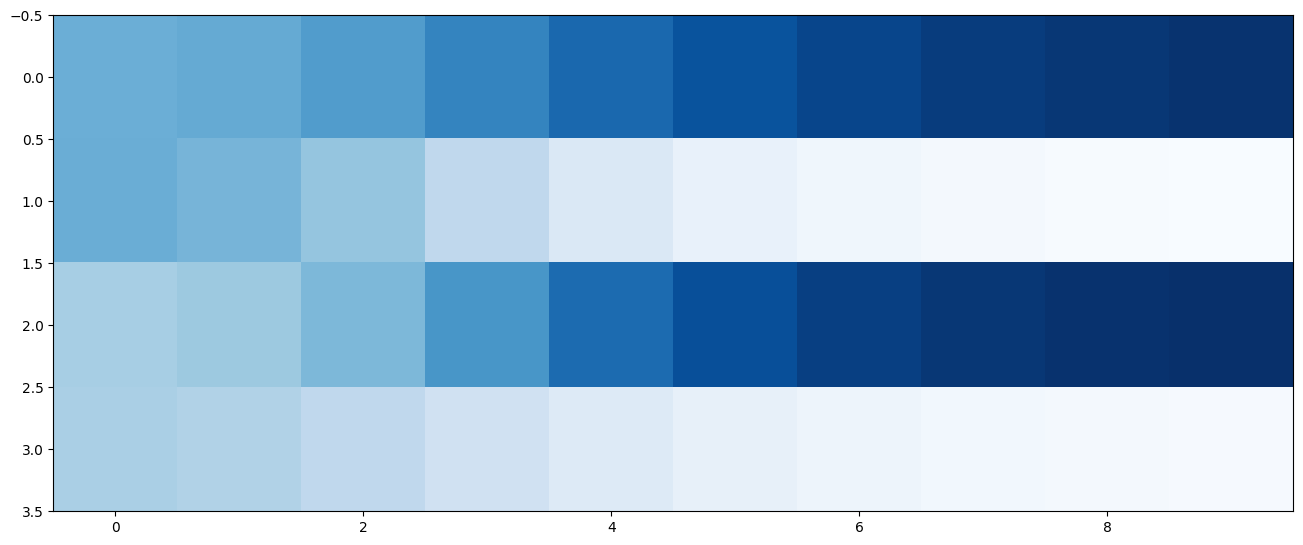

In [12]:
#################################
import matplotlib.pyplot as plt
import os

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import numpy as np

plt.figure(figsize=(16, 8))
plt.imshow(np.array(image_list).T, interpolation='none', cmap='Blues')
plt.show()